In [60]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from IPython.display import display


In [61]:
from scipy.stats import beta as beta_dist

def bci(successes, trials, confidence=0.05):
    if trials == 0:
        return 0.0
    s = successes if isinstance(successes, (int, float)) else successes
    n = trials
    return beta_dist.ppf(confidence, s + 1, n - s + 1)

def bci_from_rate(rate, assumed_n=50):
    s = round(rate * assumed_n)
    return bci(s, assumed_n)

def edp(x, k):
    return np.exp(-k * x)

def ln_norm(count, cap):
    if cap <= 0:
        return 0.0
    return min(np.log(1 + count) / np.log(1 + cap), 1.0)

def gaussian_penalty(actual, ideal, sigma):
    return np.exp(-((actual - ideal) ** 2) / (2 * sigma ** 2))

def hrc(values, weights, delta=0.15, max_iter=100, tol=1e-6):
    values = np.array(values, dtype=float)
    weights = np.array(weights, dtype=float)
    weights = weights / weights.sum() 
    theta = np.dot(weights, values)
    for _ in range(max_iter):
        residuals = np.abs(values - theta)
        adjusted_weights = weights.copy()
        for i in range(len(values)):
            if residuals[i] > delta:
                adjusted_weights[i] = weights[i] * (delta / residuals[i])
        if adjusted_weights.sum() == 0:
            break
        theta_new = np.dot(adjusted_weights, values) / adjusted_weights.sum()
        
        if abs(theta_new - theta) < tol:
            theta = theta_new
            break
        theta = theta_new
    return theta

In [62]:
def calculate_employee_score(data, gates, modifiers, weights):
    
    p1 = data[0] 
    Tc = bci(p1["tvnum"], round( p1["tvnum"]/ p1["tc"]))
    Tv = min(p1["tvnum"] / p1["tvbench"], 1.3) / 1.3
    assumed_deliverables = 20
    Dd = bci(round(p1["dd"] * assumed_deliverables), assumed_deliverables)
    Ad = edp(p1["adraw"], 0.15)
    assumed_hp = 10
    Pr = bci(round(p1["pr"] * assumed_hp), assumed_hp)
    esc_count = round(p1["escraw"] * p1["tvnum"])
    Esc = 1.0 - bci(esc_count, p1["tvnum"])
    rw_count = round(p1["rwraw"] * p1["tvnum"])
    Rw = 1.0 - bci(rw_count, p1["tvnum"])
    T_core = hrc(values=[Tc, Dd, Ad, Pr],weights=[0.30, 0.25, 0.20, 0.25]) 
    T_drag = hrc(values=[Esc, Rw],weights=[0.50, 0.50])
    X1 = 0.60 * T_core + 0.20 * Tv + 0.20 * T_drag

    p2 = data[1]
    Qa = p2["qa"]    
    assumed_submissions = 50
    Fa = bci(round(p2["fa"] * assumed_submissions), assumed_submissions)
    Dr = edp(p2["drraw"], 0.4)
    Cs = p2["cs"]   
    Dt = p2["dt"] 
    Cr = p2["cr"]  
    Q_out = hrc(values=[Qa, Fa, Dr, Cs, Dt],weights=[0.25, 0.20, 0.20, 0.15, 0.20])
    X2 = 0.85 * Q_out + 0.15 * Cr

    p3 = data[2]
    Cv = np.exp(-2 * np.sqrt(p3["cvsigma"] ** 2))
    Dp = p3["dp"]  
    assumed_commitments = 20
    Fs = bci(round(p3["fs"] * assumed_commitments), assumed_commitments)
    assumed_critical = 5
    Av = bci(round(p3["av"] * assumed_critical), assumed_critical)
    Pm = 1.0 - min(abs(p3["pmactual"] - p3["pmest"]) / p3["pmest"], 1.0)
    X3 = hrc(values=[Cv, Dp, Fs, Av, Pm],weights=[0.25, 0.25, 0.25, 0.10, 0.15])
    
    p4 = data[3]
    Tc4 = p4["tc4"]  
    Cm = p4["cm"]     
    Rsp = edp(p4["rsphours"], 0.05)
    Cf = p4["cf"]   
    Kn = p4["kn"]    
    Fb = p4["fb"]      
    assumed_handoffs = 60
    bl_count = round(p4["blraw"] * assumed_handoffs)
    Bl = 1.0 - bci(bl_count, assumed_handoffs)
    C_pos = hrc(values=[Tc4, Cm, Rsp, Cf, Kn, Fb],weights=[0.25, 0.20, 0.15, 0.10, 0.15, 0.15])
    X4 = C_pos * Bl

    p5 = data[4]
    In = ln_norm(p5["incount"], 10)
    Ow = p5["ow"]     
    Ps = p5["ps"]    
    Au = p5["au"]    
    Bc = ln_norm(p5["bccount"], 5)
    Imp = p5["imp"]  
    X5 = hrc(values=[In, Ow, Ps, Au, Bc, Imp], weights=[0.20, 0.25, 0.20, 0.15, 0.10, 0.10])
    
    p6 = data[5]
    Sk = ln_norm(p6["skcount"], 5)
    Pd = p6["pd"]      
    Ad6 = p6["ad6"]  
    Fp = p6["fp"]   
    Lr = p6["lr"]   
    Vr = min(p6["vrroles"] / 3.0, 1.0)
    X6 = hrc(values=[Sk, Pd, Ad6, Fp, Lr, Vr], weights=[0.20, 0.15, 0.25, 0.20, 0.10, 0.10])

    p7 = data[6]
    Ut = p7["ut"]     
    Et = p7["et"]  
    Rt = p7["rt"] 
    assumed_meetings = 20
    Mt = bci(round(p7["mt"] * assumed_meetings), assumed_meetings)
    Ot = edp(max(0, p7["otratio"] - 0.10), 2.0)
    Wm = 1.0 - p7["wmraw"]
    X7 = hrc(values=[Ut, Et, Rt, Mt, Ot, Wm], weights=[0.25, 0.25, 0.15, 0.10, 0.15, 0.10])

    p8 = data[7]
    assumed_tasks_8 = 50
    Ga = bci(round(p8["ga"] * assumed_tasks_8), assumed_tasks_8)
    assumed_goals = 5
    Gc = bci(round(p8["gc"] * assumed_goals), assumed_goals)
    St = p8["st"]   
    Pv = p8["pv"]
    Vi = p8["vi"] 
    X8 = hrc(values=[Ga, Gc, St, Pv, Vi], weights=[0.25, 0.30, 0.15, 0.15, 0.15])

    p9 = data[8]
    Mn = ln_norm(p9["mncount"], 4)
    Inf = p9["inf"] 
    De = p9["de"]   
    Dm = p9["dm"]     
    Te = p9["te"]  
    Cr9 = p9["cr9"] 
    X9 = hrc(values=[Mn, Inf, De, Dm, Te, Cr9], weights=[0.15, 0.20, 0.15, 0.20, 0.20, 0.10])
    
    p10 = data[9]
    Va = p10["va"]
    Eth = p10["eth"]
    Po = p10["po"]
    Ev = ln_norm(p10["evcount"], 6)
    Ng = max(0, 1.0 - 0.2 * p10["ngcount"])
    Prc = p10["prc"] 
    C_cit = hrc(values=[Va, Eth, Po, Ev, Prc], weights=[0.25, 0.25, 0.20, 0.15, 0.15])
    X10 = Ng * C_cit
    
    p11 = data[10]
    assumed_workdays = 200
    At = bci(round(p11["at"] * assumed_workdays), assumed_workdays)
    Pu = bci(round(p11["pu"] * assumed_workdays), assumed_workdays)
    ua_count = round(p11["uaraw"] * assumed_workdays)
    Ua = 1.0 - bci(ua_count, assumed_workdays)
    Bn = 1.0 - p11["bn"]
    Wl = gaussian_penalty(p11["wlratio"], 1.0, 0.20)
    Lv = gaussian_penalty(p11["lvratio"], p11["lvtarget"], 0.15)
    X11 = hrc(values=[At, Pu, Ua, Bn, Wl, Lv], weights=[0.25, 0.15, 0.20, 0.15, 0.15, 0.10])
    
    p12 = data[11]
    Csat = p12["csat"] 
    Cfb = ln_norm(p12["cfbcount"], 10)
    assumed_accounts = 20
    Ret = bci(round(p12["ret"] * assumed_accounts), assumed_accounts)
    Rev = min(p12["revattributed"] / p12["revtarget"], 1.2) / 1.2
    Nc = max(0, 1.0 - 0.15 * p12["nccount"])
    Re = p12["re"]   
    S_impact = hrc(values=[Csat, Cfb, Ret, Rev, Re], weights=[0.25, 0.15, 0.20, 0.20, 0.20])
    X12 = Nc * S_impact

    g=[]
    for i in range(len(gates)):
        h=gates[i]
        if h == 't':
            g.append(0)
        else:
            g.append(1)
    G=1
    for h in g:
        G=G*h

    a=[]
    for i in range(len(modifiers)):
        h=modifiers[i]
        a.append(h)
    M=1
    for i in range(5):
        M=M*a[i]

    def sigmoid_transform(x, x0=0.50, k=8.0):
        return 1.0 / (1.0 + np.exp(-k * (x - x0)))
    def mu(S, a, a_ij):
        value = sum(a[i] for i in S)
        for (i, j), coeff in a_ij.items():
            if i in S and j in S:
                value += coeff
        return value
    def choquet_integral(scores, a, a_ij):
        n = len(scores)
        sigma = sorted(range(n), key=lambda i: scores[i])
        integral = 0.0
        for rank in range(n):
            coalition = set(sigma[rank:])
            mu_val = mu(coalition, a, a_ij)
            if rank == 0:
                delta = scores[sigma[rank]]
            else:
                delta = scores[sigma[rank]] - scores[sigma[rank - 1]]
            integral += delta * mu_val
        return integral

    X_all_raw = [X1, X2, X3, X4, X5, X6, X7, X8, X9, X10, X11, X12]
    sigmoid_index=[3,4,5,7,8,9]
    X_sig = [sigmoid_transform(x) if i in sigmoid_index else x for i, x in enumerate(X_all_raw)]
    X_final = [max(0.0, min(1.0, x)) for x in X_sig]
    a_vals = {0:0.120, 1:0.105, 2:0.090, 3:0.085, 4:0.080,
              5:0.070, 6:0.065, 7:0.080, 8:0.055, 9:0.045,
              10:0.050, 11:0.050}
    a_ij_vals = {
        (0,1):+0.025, (0,2):+0.020, (4,2):+0.015, (1,6):+0.015,
        (4,5):+0.015, (7,11):+0.020, (8,9):+0.010,
        (0,6):-0.010, (3,8):-0.010, (2,10):-0.010, (5,4):-0.005,
    }
    C_mu = choquet_integral(X_final, a_vals, a_ij_vals)
    mu_N = mu(set(range(12)), a_vals, a_ij_vals)
              
    S = 100.0 * G * M * (C_mu / mu_N)
    
    return {
        "score":       S,
        "gate_result": G,
        "modifier":    round(M, 4),
        "x1":          round(X1,  4),
        "x2":          round(X2,  4),
        "x3":          round(X3,  4),
        "x4":          round(X4,  4),
        "x5":          round(X5,  4),
        "x6":          round(X6,  4),
        "x7":          round(X7,  4),
        "x8":          round(X8,  4),
        "x9":          round(X9,  4),
        "x10":         round(X10, 4),
        "x11":         round(X11, 4),
        "x12":         round(X12, 4)
    }

In [63]:
DEFAULT_WEIGHTS = [0.15, 0.12, 0.11, 0.10, 0.10, 0.08, 0.07, 0.08, 0.07, 0.06, 0.04, 0.02]

test_cases = [

    {
        "case_id": "EMP01",
        "label":   "Star Performer — All-Round Exceptional",
        "summary": "Top-quartile employee across every dimension. High output, quality, "
                   "reliability, leadership, and client impact. The benchmark.",
        "data": [
            # P1 — Task & Deliverable Performance
            {"tc": 0.96, "tvnum": 60, "tvbench": 45, "dd": 0.95, "adraw": 0.5,
             "pr": 0.98, "escraw": 0.02, "rwraw": 0.03},
            # P2 — Quality of Work
            {"qa": 0.95, "fa": 0.92, "drraw": 0.3, "cs": 0.96, "dt": 0.95, "cr": 0.90},
            # P3 — Reliability & Consistency
            {"cvsigma": 0.04, "dp": 0.97, "fs": 0.98, "av": 0.95, "pmest": 5.0, "pmactual": 4.8},
            # P4 — Collaboration & Communication
            {"tc4": 0.95, "cm": 0.92, "rsphours": 1.0, "cf": 0.90, "kn": 0.92, "fb": 0.95, "blraw": 0.01},
            # P5 — Initiative, Ownership & Problem-Solving
            {"incount": 8, "ow": 0.95, "ps": 0.93, "au": 0.95, "bccount": 5, "imp": 0.90},
            # P6 — Learning, Growth & Adaptability
            {"skcount": 4, "pd": 0.90, "ad6": 0.95, "fp": 0.95, "lr": 0.92, "vrroles": 4},
            # P7 — Time & Resource Efficiency
            {"ut": 0.92, "et": 0.95, "rt": 0.90, "mt": 0.88, "otratio": 0.08, "wmraw": 0.04},
            # P8 — Goal Alignment & Strategic Contribution
            {"ga": 0.95, "gc": 0.95, "st": 0.92, "pv": 0.93, "vi": 0.90},
            # P9 — Leadership & Influence
            {"mncount": 4, "inf": 0.90, "de": 0.88, "dm": 0.92, "te": 0.90, "cr9": 0.92},
            # P10 — Cultural Fit & Organisational Citizenship
            {"va": 0.95, "eth": 0.98, "po": 0.95, "evcount": 6, "ngcount": 0, "prc": 0.96},
            # P11 — Availability, Attendance & Workload Health
            {"at": 0.98, "pu": 0.97, "uaraw": 0.01, "bn": 0.10, "wlratio": 1.10, "lvratio": 0.08, "lvtarget": 0.08},
            # P12 — Client & Stakeholder Impact
            {"csat": 0.96, "cfbcount": 12, "ret": 0.95, "revattributed": 1800000, "revtarget": 1200000, "nccount": 0, "re": 0.95},
        ],
        "gates":     ["f","f","f","f","f","f","f"],
        "modifiers": [1.0, 1.0, 1.0, 1.0, 1.0],
        "weights":   DEFAULT_WEIGHTS,
    },

    {
        "case_id": "EMP02",
        "label":   "Solid Mid-Performer — Dependable but Plateaued",
        "summary": "Reliable, consistent employee meeting expectations but showing little "
                   "growth ambition. Good quality, low initiative, no red flags.",
        "data": [
            {"tc": 0.85, "tvnum": 44, "tvbench": 45, "dd": 0.82, "adraw": 3.0,
             "pr": 0.86, "escraw": 0.10, "rwraw": 0.12},
            {"qa": 0.78, "fa": 0.74, "drraw": 1.5, "cs": 0.82, "dt": 0.75, "cr": 0.50},
            {"cvsigma": 0.08, "dp": 0.80, "fs": 0.85, "av": 0.80, "pmest": 5.0, "pmactual": 5.2},
            {"tc4": 0.75, "cm": 0.78, "rsphours": 4.0, "cf": 0.75, "kn": 0.60, "fb": 0.75, "blraw": 0.08},
            {"incount": 1, "ow": 0.75, "ps": 0.70, "au": 0.75, "bccount": 1, "imp": 0.50},
            {"skcount": 1, "pd": 0.55, "ad6": 0.70, "fp": 0.65, "lr": 0.65, "vrroles": 1},
            {"ut": 0.78, "et": 0.75, "rt": 0.72, "mt": 0.68, "otratio": 0.10, "wmraw": 0.15},
            {"ga": 0.80, "gc": 0.75, "st": 0.65, "pv": 0.70, "vi": 0.60},
            {"mncount": 1, "inf": 0.50, "de": 0.50, "dm": 0.70, "te": 0.60, "cr9": 0.65},
            {"va": 0.80, "eth": 0.85, "po": 0.75, "evcount": 2, "ngcount": 0, "prc": 0.82},
            {"at": 0.92, "pu": 0.88, "uaraw": 0.06, "bn": 0.25, "wlratio": 1.00, "lvratio": 0.08, "lvtarget": 0.08},
            {"csat": 0.76, "cfbcount": 3, "ret": 0.80, "revattributed": 980000, "revtarget": 1000000, "nccount": 1, "re": 0.65},
        ],
        "gates":     ["f","f","f","f","f","f","f"],
        "modifiers": [1.0, 1.0, 1.0, 1.0, 1.0],
        "weights":   DEFAULT_WEIGHTS,
    },

    {
        "case_id": "EMP03",
        "label":   "Underperformer — Chronic Missed Deadlines",
        "summary": "Consistently misses deadlines, high rework rate, low output volume, "
                   "poor manager trust. On a performance improvement plan.",
        "data": [
            {"tc": 0.45, "tvnum": 22, "tvbench": 45, "dd": 0.40, "adraw": 12.0,
             "pr": 0.50, "escraw": 0.35, "rwraw": 0.40},
            {"qa": 0.45, "fa": 0.35, "drraw": 4.5, "cs": 0.50, "dt": 0.40, "cr": 0.40},
            {"cvsigma": 0.28, "dp": 0.30, "fs": 0.45, "av": 0.55, "pmest": 5.0, "pmactual": 9.5},
            {"tc4": 0.45, "cm": 0.50, "rsphours": 12.0, "cf": 0.40, "kn": 0.35, "fb": 0.40, "blraw": 0.30},
            {"incount": 0, "ow": 0.30, "ps": 0.35, "au": 0.30, "bccount": 0, "imp": 0.10},
            {"skcount": 0, "pd": 0.25, "ad6": 0.35, "fp": 0.20, "lr": 0.30, "vrroles": 1},
            {"ut": 0.50, "et": 0.40, "rt": 0.55, "mt": 0.45, "otratio": 0.30, "wmraw": 0.35},
            {"ga": 0.50, "gc": 0.35, "st": 0.30, "pv": 0.35, "vi": 0.20},
            {"mncount": 0, "inf": 0.20, "de": 0.50, "dm": 0.35, "te": 0.25, "cr9": 0.30},
            {"va": 0.60, "eth": 0.70, "po": 0.50, "evcount": 0, "ngcount": 1, "prc": 0.55},
            {"at": 0.78, "pu": 0.70, "uaraw": 0.18, "bn": 0.55, "wlratio": 0.70, "lvratio": 0.02, "lvtarget": 0.08},
            {"csat": 0.45, "cfbcount": 0, "ret": 0.60, "revattributed": 300000, "revtarget": 900000, "nccount": 4, "re": 0.35},
        ],
        "gates":     ["f","f","f","f","f","f","f"],
        "modifiers": [0.7, 0.8, 0.8, 0.9, 0.9],
        "weights":   DEFAULT_WEIGHTS,
    },

    {
        "case_id": "EMP04",
        "label":   "Gate Kill — Serious Conduct Violation",
        "summary": "Employee has 6 confirmed behavioural incidents this period (harassment "
                   "complaints). P10 ngcount >= 5 triggers parameter zero. Gate also fires.",
        "data": [
            {"tc": 0.82, "tvnum": 44, "tvbench": 45, "dd": 0.80, "adraw": 3.0,
             "pr": 0.82, "escraw": 0.10, "rwraw": 0.12},
            {"qa": 0.78, "fa": 0.72, "drraw": 1.5, "cs": 0.80, "dt": 0.75, "cr": 0.65},
            {"cvsigma": 0.10, "dp": 0.75, "fs": 0.82, "av": 0.80, "pmest": 5.0, "pmactual": 5.5},
            {"tc4": 0.60, "cm": 0.70, "rsphours": 4.0, "cf": 0.30, "kn": 0.55, "fb": 0.50, "blraw": 0.12},
            {"incount": 2, "ow": 0.70, "ps": 0.72, "au": 0.75, "bccount": 1, "imp": 0.55},
            {"skcount": 1, "pd": 0.60, "ad6": 0.65, "fp": 0.60, "lr": 0.65, "vrroles": 2},
            {"ut": 0.78, "et": 0.75, "rt": 0.72, "mt": 0.65, "otratio": 0.12, "wmraw": 0.14},
            {"ga": 0.78, "gc": 0.72, "st": 0.65, "pv": 0.70, "vi": 0.60},
            {"mncount": 1, "inf": 0.55, "de": 0.50, "dm": 0.70, "te": 0.55, "cr9": 0.60},
            {"va": 0.20, "eth": 0.10, "po": 0.15, "evcount": 1, "ngcount": 6, "prc": 0.30},
            {"at": 0.90, "pu": 0.85, "uaraw": 0.07, "bn": 0.30, "wlratio": 1.05, "lvratio": 0.06, "lvtarget": 0.08},
            {"csat": 0.70, "cfbcount": 2, "ret": 0.75, "revattributed": 900000, "revtarget": 900000, "nccount": 3, "re": 0.55},
        ],
        "gates":     ["f","f","f","f","t","f","f"],   # G5 = conduct/HR gate
        "modifiers": [1.0, 1.0, 1.0, 1.0, 1.0],
        "weights":   DEFAULT_WEIGHTS,
    },

    {
        "case_id": "EMP05",
        "label":   "Brilliant Specialist — High Quality, Low Collaboration",
        "summary": "Exceptional technical output but works in isolation, poor communicator, "
                   "knowledge hoarder, slow responder. Classic lone genius.",
        "data": [
            {"tc": 0.90, "tvnum": 50, "tvbench": 45, "dd": 0.88, "adraw": 1.5,
             "pr": 0.92, "escraw": 0.05, "rwraw": 0.06},
            {"qa": 0.95, "fa": 0.90, "drraw": 0.3, "cs": 0.92, "dt": 0.96, "cr": 0.95},
            {"cvsigma": 0.06, "dp": 0.90, "fs": 0.92, "av": 0.85, "pmest": 6.0, "pmactual": 5.8},
            {"tc4": 0.30, "cm": 0.35, "rsphours": 18.0, "cf": 0.30, "kn": 0.15, "fb": 0.45, "blraw": 0.35},
            {"incount": 5, "ow": 0.85, "ps": 0.95, "au": 0.98, "bccount": 0, "imp": 0.85},
            {"skcount": 3, "pd": 0.85, "ad6": 0.60, "fp": 0.70, "lr": 0.90, "vrroles": 1},
            {"ut": 0.90, "et": 0.92, "rt": 0.85, "mt": 0.40, "otratio": 0.20, "wmraw": 0.06},
            {"ga": 0.75, "gc": 0.85, "st": 0.60, "pv": 0.80, "vi": 0.85},
            {"mncount": 0, "inf": 0.50, "de": 0.20, "dm": 0.80, "te": 0.30, "cr9": 0.75},
            {"va": 0.75, "eth": 0.90, "po": 0.50, "evcount": 0, "ngcount": 0, "prc": 0.75},
            {"at": 0.95, "pu": 0.92, "uaraw": 0.03, "bn": 0.40, "wlratio": 1.25, "lvratio": 0.03, "lvtarget": 0.08},
            {"csat": 0.80, "cfbcount": 4, "ret": 0.85, "revattributed": 1400000, "revtarget": 1000000, "nccount": 1, "re": 0.55},
        ],
        "gates":     ["f","f","f","f","f","f","f"],
        "modifiers": [1.0, 1.0, 0.9, 1.0, 1.0],
        "weights":   DEFAULT_WEIGHTS,
    },

    {
        "case_id": "EMP06",
        "label":   "Burnout Risk — Overloaded High Performer",
        "summary": "Excellent output historically but now showing severe burnout signals: "
                   "massive overtime, no leave taken, declining consistency, high absenteeism.",
        "data": [
            {"tc": 0.78, "tvnum": 68, "tvbench": 45, "dd": 0.75, "adraw": 5.0,
             "pr": 0.80, "escraw": 0.12, "rwraw": 0.18},
            {"qa": 0.75, "fa": 0.70, "drraw": 2.0, "cs": 0.78, "dt": 0.72, "cr": 0.60},
            {"cvsigma": 0.22, "dp": 0.70, "fs": 0.75, "av": 0.70, "pmest": 4.0, "pmactual": 6.5},
            {"tc4": 0.65, "cm": 0.68, "rsphours": 6.0, "cf": 0.60, "kn": 0.55, "fb": 0.65, "blraw": 0.15},
            {"incount": 2, "ow": 0.80, "ps": 0.75, "au": 0.78, "bccount": 1, "imp": 0.60},
            {"skcount": 0, "pd": 0.35, "ad6": 0.55, "fp": 0.60, "lr": 0.65, "vrroles": 2},
            {"ut": 0.70, "et": 0.72, "rt": 0.68, "mt": 0.58, "otratio": 0.45, "wmraw": 0.20},
            {"ga": 0.78, "gc": 0.70, "st": 0.68, "pv": 0.65, "vi": 0.65},
            {"mncount": 1, "inf": 0.60, "de": 0.50, "dm": 0.70, "te": 0.60, "cr9": 0.55},
            {"va": 0.80, "eth": 0.88, "po": 0.65, "evcount": 0, "ngcount": 0, "prc": 0.78},
            {"at": 0.80, "pu": 0.75, "uaraw": 0.16, "bn": 0.85, "wlratio": 1.70, "lvratio": 0.01, "lvtarget": 0.08},
            {"csat": 0.72, "cfbcount": 2, "ret": 0.78, "revattributed": 950000, "revtarget": 1000000, "nccount": 2, "re": 0.65},
        ],
        "gates":     ["f","f","f","f","f","f","f"],
        "modifiers": [0.9, 1.0, 1.0, 1.0, 0.8],
        "weights":   DEFAULT_WEIGHTS,
    },

    {
        "case_id": "EMP07",
        "label":   "New Hire — 3 Months In, High Potential",
        "summary": "Recently joined employee, still ramping. Output low but quality already "
                   "strong. Learning fast, great attitude. First evaluation.",
        "data": [
            {"tc": 0.75, "tvnum": 18, "tvbench": 45, "dd": 0.78, "adraw": 4.0,
             "pr": 0.80, "escraw": 0.20, "rwraw": 0.20},
            {"qa": 0.80, "fa": 0.72, "drraw": 1.8, "cs": 0.82, "dt": 0.78, "cr": 0.70},
            {"cvsigma": 0.15, "dp": 0.70, "fs": 0.80, "av": 0.85, "pmest": 5.0, "pmactual": 6.5},
            {"tc4": 0.80, "cm": 0.78, "rsphours": 3.0, "cf": 0.80, "kn": 0.65, "fb": 0.92, "blraw": 0.08},
            {"incount": 1, "ow": 0.75, "ps": 0.72, "au": 0.60, "bccount": 0, "imp": 0.50},
            {"skcount": 3, "pd": 0.90, "ad6": 0.90, "fp": 0.50, "lr": 0.92, "vrroles": 1},
            {"ut": 0.80, "et": 0.65, "rt": 0.78, "mt": 0.75, "otratio": 0.05, "wmraw": 0.15},
            {"ga": 0.75, "gc": 0.65, "st": 0.60, "pv": 0.68, "vi": 0.45},
            {"mncount": 0, "inf": 0.35, "de": 0.50, "dm": 0.68, "te": 0.55, "cr9": 0.65},
            {"va": 0.92, "eth": 0.95, "po": 0.90, "evcount": 4, "ngcount": 0, "prc": 0.90},
            {"at": 0.98, "pu": 0.97, "uaraw": 0.01, "bn": 0.10, "wlratio": 0.80, "lvratio": 0.02, "lvtarget": 0.08},
            {"csat": 0.78, "cfbcount": 2, "ret": 0.50, "revattributed": 200000, "revtarget": 200000, "nccount": 0, "re": 0.65},
        ],
        "gates":     ["f","f","f","f","f","f","f"],
        "modifiers": [0.8, 1.0, 1.0, 1.0, 1.0],
        "weights":   DEFAULT_WEIGHTS,
    },

    {
        "case_id": "EMP08",
        "label":   "Gate Kill — Excessive Client Complaints (7+)",
        "summary": "Sales executive with strong numbers but 8 formal client complaints this "
                   "period. nccount >= 7 in P12 causes significant score collapse.",
        "data": [
            {"tc": 0.88, "tvnum": 52, "tvbench": 45, "dd": 0.85, "adraw": 2.0,
             "pr": 0.90, "escraw": 0.08, "rwraw": 0.10},
            {"qa": 0.78, "fa": 0.75, "drraw": 1.2, "cs": 0.80, "dt": 0.75, "cr": 0.70},
            {"cvsigma": 0.10, "dp": 0.82, "fs": 0.88, "av": 0.85, "pmest": 4.0, "pmactual": 4.2},
            {"tc4": 0.72, "cm": 0.70, "rsphours": 3.5, "cf": 0.40, "kn": 0.60, "fb": 0.60, "blraw": 0.10},
            {"incount": 3, "ow": 0.82, "ps": 0.78, "au": 0.82, "bccount": 2, "imp": 0.70},
            {"skcount": 1, "pd": 0.65, "ad6": 0.72, "fp": 0.70, "lr": 0.70, "vrroles": 2},
            {"ut": 0.85, "et": 0.88, "rt": 0.80, "mt": 0.72, "otratio": 0.15, "wmraw": 0.10},
            {"ga": 0.88, "gc": 0.85, "st": 0.78, "pv": 0.82, "vi": 0.80},
            {"mncount": 2, "inf": 0.68, "de": 0.65, "dm": 0.75, "te": 0.65, "cr9": 0.70},
            {"va": 0.70, "eth": 0.65, "po": 0.60, "evcount": 2, "ngcount": 2, "prc": 0.68},
            {"at": 0.93, "pu": 0.90, "uaraw": 0.05, "bn": 0.28, "wlratio": 1.15, "lvratio": 0.07, "lvtarget": 0.08},
            {"csat": 0.35, "cfbcount": 1, "ret": 0.55, "revattributed": 1500000, "revtarget": 1200000, "nccount": 8, "re": 0.30},
        ],
        "gates":     ["f","f","f","f","f","f","f"],
        "modifiers": [1.0, 1.0, 1.0, 1.0, 0.5],
        "weights":   DEFAULT_WEIGHTS,
    },

    {
        "case_id": "EMP09",
        "label":   "Remote Worker — Highly Autonomous, Low Visibility",
        "summary": "Fully remote employee delivering solid output but low engagement in "
                   "team activities, culture, and visibility. Hard to observe accurately.",
        "data": [
            {"tc": 0.85, "tvnum": 46, "tvbench": 45, "dd": 0.83, "adraw": 3.5,
             "pr": 0.87, "escraw": 0.09, "rwraw": 0.11},
            {"qa": 0.82, "fa": 0.78, "drraw": 1.3, "cs": 0.85, "dt": 0.80, "cr": 0.68},
            {"cvsigma": 0.09, "dp": 0.88, "fs": 0.90, "av": 0.82, "pmest": 5.0, "pmactual": 5.2},
            {"tc4": 0.60, "cm": 0.72, "rsphours": 5.0, "cf": 0.70, "kn": 0.50, "fb": 0.78, "blraw": 0.10},
            {"incount": 3, "ow": 0.85, "ps": 0.82, "au": 0.95, "bccount": 1, "imp": 0.68},
            {"skcount": 2, "pd": 0.72, "ad6": 0.78, "fp": 0.75, "lr": 0.75, "vrroles": 2},
            {"ut": 0.88, "et": 0.85, "rt": 0.82, "mt": 0.55, "otratio": 0.08, "wmraw": 0.10},
            {"ga": 0.82, "gc": 0.80, "st": 0.72, "pv": 0.78, "vi": 0.68},
            {"mncount": 1, "inf": 0.52, "de": 0.50, "dm": 0.78, "te": 0.55, "cr9": 0.75},
            {"va": 0.78, "eth": 0.88, "po": 0.62, "evcount": 1, "ngcount": 0, "prc": 0.80},
            {"at": 0.95, "pu": 0.94, "uaraw": 0.03, "bn": 0.22, "wlratio": 1.05, "lvratio": 0.07, "lvtarget": 0.08},
            {"csat": 0.80, "cfbcount": 3, "ret": 0.82, "revattributed": 980000, "revtarget": 1000000, "nccount": 1, "re": 0.68},
        ],
        "gates":     ["f","f","f","f","f","f","f"],
        "modifiers": [1.0, 1.0, 1.0, 0.9, 1.0],
        "weights":   DEFAULT_WEIGHTS,
    },

    {
        "case_id": "EMP10",
        "label":   "Senior Leader — Strategic, Less Hands-On",
        "summary": "VP-level employee with strong leadership, strategy, and influence scores "
                   "but lower personal task output. Tests whether leadership dims raw throughput.",
        "data": [
            {"tc": 0.80, "tvnum": 28, "tvbench": 25, "dd": 0.82, "adraw": 2.0,
             "pr": 0.88, "escraw": 0.05, "rwraw": 0.06},
            {"qa": 0.88, "fa": 0.82, "drraw": 0.8, "cs": 0.88, "dt": 0.85, "cr": 0.80},
            {"cvsigma": 0.08, "dp": 0.92, "fs": 0.92, "av": 0.90, "pmest": 10.0, "pmactual": 10.5},
            {"tc4": 0.90, "cm": 0.95, "rsphours": 2.0, "cf": 0.90, "kn": 0.90, "fb": 0.88, "blraw": 0.03},
            {"incount": 6, "ow": 0.92, "ps": 0.90, "au": 0.95, "bccount": 8, "imp": 0.88},
            {"skcount": 2, "pd": 0.80, "ad6": 0.88, "fp": 0.88, "lr": 0.82, "vrroles": 4},
            {"ut": 0.85, "et": 0.80, "rt": 0.88, "mt": 0.90, "otratio": 0.10, "wmraw": 0.08},
            {"ga": 0.95, "gc": 0.90, "st": 0.98, "pv": 0.95, "vi": 0.92},
            {"mncount": 6, "inf": 0.95, "de": 0.95, "dm": 0.95, "te": 0.95, "cr9": 0.92},
            {"va": 0.92, "eth": 0.95, "po": 0.92, "evcount": 5, "ngcount": 0, "prc": 0.95},
            {"at": 0.92, "pu": 0.90, "uaraw": 0.04, "bn": 0.25, "wlratio": 1.20, "lvratio": 0.09, "lvtarget": 0.08},
            {"csat": 0.90, "cfbcount": 8, "ret": 0.92, "revattributed": 5000000, "revtarget": 4000000, "nccount": 0, "re": 0.95},
        ],
        "gates":     ["f","f","f","f","f","f","f"],
        "modifiers": [1.0, 1.0, 1.0, 1.0, 1.0],
        "weights":   DEFAULT_WEIGHTS,
    },

    {
        "case_id": "EMP11",
        "label":   "People Pleaser — High Perceived Likability, Low Output",
        "summary": "Very liked by the team and management, always at events, but actual task "
                   "completion and quality are mediocre. Soft scores mask hard performance.",
        "data": [
            {"tc": 0.62, "tvnum": 30, "tvbench": 45, "dd": 0.58, "adraw": 8.0,
             "pr": 0.65, "escraw": 0.22, "rwraw": 0.28},
            {"qa": 0.60, "fa": 0.55, "drraw": 3.0, "cs": 0.65, "dt": 0.55, "cr": 0.50},
            {"cvsigma": 0.18, "dp": 0.65, "fs": 0.62, "av": 0.75, "pmest": 4.0, "pmactual": 7.5},
            {"tc4": 0.88, "cm": 0.90, "rsphours": 1.5, "cf": 0.90, "kn": 0.82, "fb": 0.88, "blraw": 0.05},
            {"incount": 2, "ow": 0.55, "ps": 0.50, "au": 0.50, "bccount": 3, "imp": 0.35},
            {"skcount": 1, "pd": 0.60, "ad6": 0.70, "fp": 0.55, "lr": 0.58, "vrroles": 1},
            {"ut": 0.62, "et": 0.55, "rt": 0.70, "mt": 0.80, "otratio": 0.05, "wmraw": 0.28},
            {"ga": 0.60, "gc": 0.52, "st": 0.55, "pv": 0.50, "vi": 0.40},
            {"mncount": 2, "inf": 0.75, "de": 0.50, "dm": 0.60, "te": 0.70, "cr9": 0.50},
            {"va": 0.88, "eth": 0.85, "po": 0.95, "evcount": 8, "ngcount": 0, "prc": 0.90},
            {"at": 0.96, "pu": 0.95, "uaraw": 0.02, "bn": 0.12, "wlratio": 0.72, "lvratio": 0.10, "lvtarget": 0.08},
            {"csat": 0.78, "cfbcount": 6, "ret": 0.72, "revattributed": 500000, "revtarget": 900000, "nccount": 0, "re": 0.82},
        ],
        "gates":     ["f","f","f","f","f","f","f"],
        "modifiers": [1.0, 1.0, 1.0, 1.0, 1.0],
        "weights":   DEFAULT_WEIGHTS,
    },

    {
        "case_id": "EMP12",
        "label":   "Flight Risk — Disengaged High Performer",
        "summary": "Top performer by numbers, but recent disengagement signals: "
                   "low initiative, declining culture participation, minimal development. "
                   "Likely exploring exit.",
        "data": [
            {"tc": 0.91, "tvnum": 50, "tvbench": 45, "dd": 0.90, "adraw": 1.5,
             "pr": 0.93, "escraw": 0.05, "rwraw": 0.07},
            {"qa": 0.90, "fa": 0.87, "drraw": 0.6, "cs": 0.90, "dt": 0.88, "cr": 0.55},
            {"cvsigma": 0.07, "dp": 0.88, "fs": 0.90, "av": 0.78, "pmest": 5.0, "pmactual": 5.0},
            {"tc4": 0.65, "cm": 0.75, "rsphours": 6.0, "cf": 0.65, "kn": 0.45, "fb": 0.50, "blraw": 0.12},
            {"incount": 0, "ow": 0.80, "ps": 0.85, "au": 0.90, "bccount": 0, "imp": 0.40},
            {"skcount": 0, "pd": 0.20, "ad6": 0.50, "fp": 0.60, "lr": 0.75, "vrroles": 2},
            {"ut": 0.88, "et": 0.90, "rt": 0.85, "mt": 0.55, "otratio": 0.05, "wmraw": 0.08},
            {"ga": 0.85, "gc": 0.88, "st": 0.65, "pv": 0.82, "vi": 0.80},
            {"mncount": 0, "inf": 0.55, "de": 0.50, "dm": 0.82, "te": 0.50, "cr9": 0.70},
            {"va": 0.60, "eth": 0.85, "po": 0.50, "evcount": 0, "ngcount": 0, "prc": 0.78},
            {"at": 0.88, "pu": 0.85, "uaraw": 0.09, "bn": 0.35, "wlratio": 0.95, "lvratio": 0.12, "lvtarget": 0.08},
            {"csat": 0.85, "cfbcount": 4, "ret": 0.88, "revattributed": 1300000, "revtarget": 1000000, "nccount": 0, "re": 0.60},
        ],
        "gates":     ["f","f","f","f","f","f","f"],
        "modifiers": [1.0, 0.9, 1.0, 1.0, 1.0],
        "weights":   DEFAULT_WEIGHTS,
    },

    {
        "case_id": "EMP13",
        "label":   "Part-Time Contractor — High Efficiency, Scoped Role",
        "summary": "Part-time contractor working 20 hrs/week. Output is proportionally "
                   "excellent, but low role breadth, minimal culture/leadership contribution.",
        "data": [
            {"tc": 0.92, "tvnum": 22, "tvbench": 22, "dd": 0.90, "adraw": 1.0,
             "pr": 0.94, "escraw": 0.04, "rwraw": 0.06},
            {"qa": 0.90, "fa": 0.88, "drraw": 0.5, "cs": 0.92, "dt": 0.88, "cr": 0.72},
            {"cvsigma": 0.06, "dp": 0.92, "fs": 0.95, "av": 0.90, "pmest": 3.0, "pmactual": 3.1},
            {"tc4": 0.65, "cm": 0.80, "rsphours": 4.0, "cf": 0.78, "kn": 0.55, "fb": 0.82, "blraw": 0.06},
            {"incount": 2, "ow": 0.88, "ps": 0.85, "au": 0.95, "bccount": 1, "imp": 0.72},
            {"skcount": 1, "pd": 0.65, "ad6": 0.80, "fp": 0.78, "lr": 0.80, "vrroles": 1},
            {"ut": 0.92, "et": 0.95, "rt": 0.88, "mt": 0.65, "otratio": 0.02, "wmraw": 0.05},
            {"ga": 0.88, "gc": 0.85, "st": 0.70, "pv": 0.85, "vi": 0.72},
            {"mncount": 0, "inf": 0.42, "de": 0.50, "dm": 0.80, "te": 0.45, "cr9": 0.78},
            {"va": 0.80, "eth": 0.92, "po": 0.72, "evcount": 1, "ngcount": 0, "prc": 0.88},
            {"at": 0.98, "pu": 0.97, "uaraw": 0.01, "bn": 0.10, "wlratio": 1.00, "lvratio": 0.05, "lvtarget": 0.08},
            {"csat": 0.88, "cfbcount": 4, "ret": 0.50, "revattributed": 600000, "revtarget": 600000, "nccount": 0, "re": 0.70},
        ],
        "gates":     ["f","f","f","f","f","f","f"],
        "modifiers": [1.0, 1.0, 1.0, 1.0, 1.0],
        "weights":   DEFAULT_WEIGHTS,
    },

    {
        "case_id": "EMP14",
        "label":   "Recovering Underperformer — Significant Turnaround",
        "summary": "Previously on a PIP, now showing strong recovery: better deadlines, "
                   "fewer reworks, improved feedback uptake. Tests upward trajectory.",
        "data": [
            {"tc": 0.78, "tvnum": 38, "tvbench": 45, "dd": 0.76, "adraw": 5.0,
             "pr": 0.78, "escraw": 0.14, "rwraw": 0.18},
            {"qa": 0.72, "fa": 0.68, "drraw": 2.2, "cs": 0.75, "dt": 0.70, "cr": 0.55},
            {"cvsigma": 0.14, "dp": 0.70, "fs": 0.78, "av": 0.78, "pmest": 5.0, "pmactual": 6.8},
            {"tc4": 0.72, "cm": 0.72, "rsphours": 5.0, "cf": 0.72, "kn": 0.60, "fb": 0.92, "blraw": 0.12},
            {"incount": 2, "ow": 0.72, "ps": 0.68, "au": 0.65, "bccount": 1, "imp": 0.55},
            {"skcount": 2, "pd": 0.78, "ad6": 0.78, "fp": 0.90, "lr": 0.72, "vrroles": 1},
            {"ut": 0.74, "et": 0.70, "rt": 0.72, "mt": 0.65, "otratio": 0.12, "wmraw": 0.18},
            {"ga": 0.75, "gc": 0.68, "st": 0.62, "pv": 0.68, "vi": 0.55},
            {"mncount": 0, "inf": 0.42, "de": 0.50, "dm": 0.65, "te": 0.55, "cr9": 0.62},
            {"va": 0.80, "eth": 0.85, "po": 0.78, "evcount": 3, "ngcount": 0, "prc": 0.80},
            {"at": 0.90, "pu": 0.88, "uaraw": 0.07, "bn": 0.30, "wlratio": 0.90, "lvratio": 0.07, "lvtarget": 0.08},
            {"csat": 0.70, "cfbcount": 2, "ret": 0.75, "revattributed": 600000, "revtarget": 800000, "nccount": 1, "re": 0.60},
        ],
        "gates":     ["f","f","f","f","f","f","f"],
        "modifiers": [1.0, 1.0, 1.0, 1.0, 1.0],
        "weights":   DEFAULT_WEIGHTS,
    },

    {
        "case_id": "EMP15",
        "label":   "Perfectionist — High Quality, Chronic Overrun",
        "summary": "Exceptional work quality but consistently delivers late because of "
                   "over-engineering. High rework avoidance, low deadline compliance.",
        "data": [
            {"tc": 0.55, "tvnum": 30, "tvbench": 45, "dd": 0.50, "adraw": 15.0,
             "pr": 0.60, "escraw": 0.06, "rwraw": 0.04},
            {"qa": 0.97, "fa": 0.95, "drraw": 0.1, "cs": 0.96, "dt": 0.99, "cr": 0.85},
            {"cvsigma": 0.10, "dp": 0.80, "fs": 0.82, "av": 0.85, "pmest": 4.0, "pmactual": 9.0},
            {"tc4": 0.72, "cm": 0.75, "rsphours": 5.0, "cf": 0.70, "kn": 0.80, "fb": 0.65, "blraw": 0.18},
            {"incount": 3, "ow": 0.88, "ps": 0.90, "au": 0.80, "bccount": 1, "imp": 0.75},
            {"skcount": 2, "pd": 0.80, "ad6": 0.62, "fp": 0.70, "lr": 0.78, "vrroles": 2},
            {"ut": 0.65, "et": 0.60, "rt": 0.78, "mt": 0.68, "otratio": 0.35, "wmraw": 0.10},
            {"ga": 0.75, "gc": 0.60, "st": 0.72, "pv": 0.55, "vi": 0.68},
            {"mncount": 1, "inf": 0.62, "de": 0.50, "dm": 0.78, "te": 0.65, "cr9": 0.68},
            {"va": 0.82, "eth": 0.90, "po": 0.75, "evcount": 2, "ngcount": 0, "prc": 0.85},
            {"at": 0.95, "pu": 0.93, "uaraw": 0.03, "bn": 0.45, "wlratio": 1.35, "lvratio": 0.04, "lvtarget": 0.08},
            {"csat": 0.88, "cfbcount": 5, "ret": 0.88, "revattributed": 950000, "revtarget": 1000000, "nccount": 0, "re": 0.78},
        ],
        "gates":     ["f","f","f","f","f","f","f"],
        "modifiers": [1.0, 1.0, 0.9, 1.0, 1.0],
        "weights":   DEFAULT_WEIGHTS,
    },

    {
        "case_id": "EMP16",
        "label":   "Strong Individual, Weak Team Fit — Cultural Misalignment",
        "summary": "Delivers results but clashes with values: low ethics score, poor culture "
                   "fit, behavioural incidents, and negative team effect.",
        "data": [
            {"tc": 0.88, "tvnum": 50, "tvbench": 45, "dd": 0.86, "adraw": 2.0,
             "pr": 0.90, "escraw": 0.06, "rwraw": 0.09},
            {"qa": 0.85, "fa": 0.82, "drraw": 0.9, "cs": 0.80, "dt": 0.82, "cr": 0.78},
            {"cvsigma": 0.09, "dp": 0.82, "fs": 0.88, "av": 0.88, "pmest": 5.0, "pmactual": 5.1},
            {"tc4": 0.45, "cm": 0.65, "rsphours": 4.0, "cf": 0.25, "kn": 0.35, "fb": 0.35, "blraw": 0.20},
            {"incount": 4, "ow": 0.85, "ps": 0.85, "au": 0.90, "bccount": 2, "imp": 0.75},
            {"skcount": 2, "pd": 0.70, "ad6": 0.65, "fp": 0.55, "lr": 0.75, "vrroles": 2},
            {"ut": 0.88, "et": 0.90, "rt": 0.82, "mt": 0.60, "otratio": 0.12, "wmraw": 0.08},
            {"ga": 0.88, "gc": 0.85, "st": 0.75, "pv": 0.85, "vi": 0.82},
            {"mncount": 1, "inf": 0.65, "de": 0.60, "dm": 0.80, "te": 0.30, "cr9": 0.72},
            {"va": 0.30, "eth": 0.35, "po": 0.25, "evcount": 0, "ngcount": 3, "prc": 0.45},
            {"at": 0.94, "pu": 0.92, "uaraw": 0.04, "bn": 0.20, "wlratio": 1.10, "lvratio": 0.07, "lvtarget": 0.08},
            {"csat": 0.78, "cfbcount": 3, "ret": 0.80, "revattributed": 1400000, "revtarget": 1000000, "nccount": 2, "re": 0.55},
        ],
        "gates":     ["f","f","f","f","f","f","f"],
        "modifiers": [1.0, 1.0, 0.8, 1.0, 1.0],
        "weights":   DEFAULT_WEIGHTS,
    },

    {
        "case_id": "EMP17",
        "label":   "Underloaded Employee — Coasting Below Capacity",
        "summary": "Comfortable, tenured employee not being challenged. Minimal output "
                   "relative to capacity, no initiative, zero growth. Classic coasting.",
        "data": [
            {"tc": 0.88, "tvnum": 24, "tvbench": 45, "dd": 0.85, "adraw": 1.0,
             "pr": 0.88, "escraw": 0.06, "rwraw": 0.08},
            {"qa": 0.80, "fa": 0.78, "drraw": 1.0, "cs": 0.82, "dt": 0.75, "cr": 0.50},
            {"cvsigma": 0.06, "dp": 0.82, "fs": 0.88, "av": 0.85, "pmest": 5.0, "pmactual": 5.0},
            {"tc4": 0.72, "cm": 0.75, "rsphours": 3.0, "cf": 0.75, "kn": 0.55, "fb": 0.72, "blraw": 0.07},
            {"incount": 0, "ow": 0.65, "ps": 0.68, "au": 0.78, "bccount": 0, "imp": 0.20},
            {"skcount": 0, "pd": 0.25, "ad6": 0.60, "fp": 0.55, "lr": 0.60, "vrroles": 1},
            {"ut": 0.55, "et": 0.50, "rt": 0.72, "mt": 0.70, "otratio": 0.00, "wmraw": 0.32},
            {"ga": 0.70, "gc": 0.65, "st": 0.55, "pv": 0.60, "vi": 0.40},
            {"mncount": 0, "inf": 0.38, "de": 0.50, "dm": 0.68, "te": 0.45, "cr9": 0.60},
            {"va": 0.80, "eth": 0.88, "po": 0.78, "evcount": 2, "ngcount": 0, "prc": 0.85},
            {"at": 0.96, "pu": 0.95, "uaraw": 0.02, "bn": 0.08, "wlratio": 0.55, "lvratio": 0.10, "lvtarget": 0.08},
            {"csat": 0.75, "cfbcount": 1, "ret": 0.78, "revattributed": 400000, "revtarget": 1000000, "nccount": 0, "re": 0.62},
        ],
        "gates":     ["f","f","f","f","f","f","f"],
        "modifiers": [0.8, 1.0, 1.0, 1.0, 1.0],
        "weights":   DEFAULT_WEIGHTS,
    },

    {
        "case_id": "EMP18",
        "label":   "Crisis Responder — Exceptional Under Pressure, Weak Routine",
        "summary": "Thrives in incidents and emergencies but struggles with routine "
                   "deliverable management. Inconsistent quality in non-crisis work.",
        "data": [
            {"tc": 0.65, "tvnum": 32, "tvbench": 45, "dd": 0.62, "adraw": 7.0,
             "pr": 0.88, "escraw": 0.10, "rwraw": 0.22},
            {"qa": 0.65, "fa": 0.58, "drraw": 2.8, "cs": 0.68, "dt": 0.60, "cr": 0.80},
            {"cvsigma": 0.25, "dp": 0.72, "fs": 0.70, "av": 0.95, "pmest": 4.0, "pmactual": 7.0},
            {"tc4": 0.80, "cm": 0.82, "rsphours": 2.5, "cf": 0.80, "kn": 0.72, "fb": 0.75, "blraw": 0.12},
            {"incount": 3, "ow": 0.82, "ps": 0.90, "au": 0.72, "bccount": 4, "imp": 0.78},
            {"skcount": 1, "pd": 0.62, "ad6": 0.92, "fp": 0.68, "lr": 0.80, "vrroles": 2},
            {"ut": 0.68, "et": 0.65, "rt": 0.70, "mt": 0.72, "otratio": 0.20, "wmraw": 0.22},
            {"ga": 0.72, "gc": 0.62, "st": 0.70, "pv": 0.60, "vi": 0.72},
            {"mncount": 1, "inf": 0.72, "de": 0.65, "dm": 0.82, "te": 0.78, "cr9": 0.98},
            {"va": 0.82, "eth": 0.88, "po": 0.80, "evcount": 3, "ngcount": 0, "prc": 0.82},
            {"at": 0.92, "pu": 0.88, "uaraw": 0.06, "bn": 0.38, "wlratio": 1.15, "lvratio": 0.06, "lvtarget": 0.08},
            {"csat": 0.78, "cfbcount": 5, "ret": 0.78, "revattributed": 880000, "revtarget": 1000000, "nccount": 1, "re": 0.72},
        ],
        "gates":     ["f","f","f","f","f","f","f"],
        "modifiers": [1.0, 1.0, 0.9, 1.0, 1.0],
        "weights":   DEFAULT_WEIGHTS,
    },

    {
        "case_id": "EMP19",
        "label":   "Mentor & Culture Carrier — Low Personal Output, High Team Lift",
        "summary": "Senior employee mentoring 5 people, runs knowledge-sharing, great culture "
                   "ambassador. Personal task throughput is low, but team performance rises.",
        "data": [
            {"tc": 0.72, "tvnum": 26, "tvbench": 35, "dd": 0.70, "adraw": 4.0,
             "pr": 0.75, "escraw": 0.08, "rwraw": 0.10},
            {"qa": 0.82, "fa": 0.78, "drraw": 1.2, "cs": 0.85, "dt": 0.80, "cr": 0.68},
            {"cvsigma": 0.09, "dp": 0.88, "fs": 0.88, "av": 0.90, "pmest": 5.0, "pmactual": 5.5},
            {"tc4": 0.95, "cm": 0.92, "rsphours": 1.5, "cf": 0.92, "kn": 0.98, "fb": 0.90, "blraw": 0.03},
            {"incount": 3, "ow": 0.80, "ps": 0.78, "au": 0.82, "bccount": 6, "imp": 0.82},
            {"skcount": 1, "pd": 0.78, "ad6": 0.85, "fp": 0.82, "lr": 0.78, "vrroles": 3},
            {"ut": 0.72, "et": 0.68, "rt": 0.78, "mt": 0.88, "otratio": 0.08, "wmraw": 0.15},
            {"ga": 0.80, "gc": 0.72, "st": 0.85, "pv": 0.78, "vi": 0.75},
            {"mncount": 5, "inf": 0.92, "de": 0.85, "dm": 0.85, "te": 0.95, "cr9": 0.80},
            {"va": 0.95, "eth": 0.96, "po": 0.98, "evcount": 7, "ngcount": 0, "prc": 0.95},
            {"at": 0.95, "pu": 0.94, "uaraw": 0.02, "bn": 0.15, "wlratio": 1.05, "lvratio": 0.09, "lvtarget": 0.08},
            {"csat": 0.85, "cfbcount": 6, "ret": 0.85, "revattributed": 750000, "revtarget": 750000, "nccount": 0, "re": 0.90},
        ],
        "gates":     ["f","f","f","f","f","f","f"],
        "modifiers": [1.0, 1.0, 1.0, 1.0, 1.0],
        "weights":   DEFAULT_WEIGHTS,
    },

    {
        "case_id": "EMP20",
        "label":   "Ghost Employee — Attendance Present, Output Absent",
        "summary": "Clocks in daily, attends meetings, never causes trouble — but produces "
                   "virtually nothing. Maximum attendance, minimum contribution. "
                   "Tests whether attendance masks total output failure.",
        "data": [
            {"tc": 0.20, "tvnum": 8, "tvbench": 45, "dd": 0.18, "adraw": 20.0,
             "pr": 0.22, "escraw": 0.60, "rwraw": 0.55},
            {"qa": 0.30, "fa": 0.22, "drraw": 6.0, "cs": 0.40, "dt": 0.25, "cr": 0.30},
            {"cvsigma": 0.30, "dp": 0.25, "fs": 0.28, "av": 0.72, "pmest": 5.0, "pmactual": 18.0},
            {"tc4": 0.55, "cm": 0.55, "rsphours": 10.0, "cf": 0.58, "kn": 0.25, "fb": 0.45, "blraw": 0.40},
            {"incount": 0, "ow": 0.20, "ps": 0.22, "au": 0.18, "bccount": 0, "imp": 0.05},
            {"skcount": 0, "pd": 0.15, "ad6": 0.30, "fp": 0.15, "lr": 0.22, "vrroles": 1},
            {"ut": 0.28, "et": 0.20, "rt": 0.45, "mt": 0.60, "otratio": 0.00, "wmraw": 0.58},
            {"ga": 0.30, "gc": 0.18, "st": 0.25, "pv": 0.22, "vi": 0.10},
            {"mncount": 0, "inf": 0.15, "de": 0.50, "dm": 0.28, "te": 0.20, "cr9": 0.22},
            {"va": 0.65, "eth": 0.72, "po": 0.68, "evcount": 2, "ngcount": 0, "prc": 0.78},
            {"at": 0.97, "pu": 0.96, "uaraw": 0.01, "bn": 0.05, "wlratio": 0.40, "lvratio": 0.09, "lvtarget": 0.08},
            {"csat": 0.30, "cfbcount": 0, "ret": 0.50, "revattributed": 100000, "revtarget": 900000, "nccount": 2, "re": 0.30},
        ],
        "gates":     ["f","f","f","f","f","f","f"],
        "modifiers": [0.5, 0.7, 0.8, 0.9, 0.9],
        "weights":   DEFAULT_WEIGHTS,
    },
]


In [64]:
results = []

for case in test_cases:
    result = calculate_employee_score(
        case["data"],
        case["gates"],
        case["modifiers"],
        case["weights"],
    )
    results.append({
        "Case ID":         case["case_id"],
        "Label":           case["label"],
        "Score":           result["score"],
        "Gate":            result["gate_result"],
        "Modifier":        result["modifier"],
        "X1":   result["x1"],
        "X2":   result["x2"],
        "X3":   result["x3"],
        "X4":   result["x4"],
        "X5":   result["x5"],
        "X6":   result["x6"],
        "X7":   result["x7"],
        "X8":   result["x8"],
        "X9":   result["x9"],
        "X10":  result["x10"],
        "X11":  result["x11"],
        "X12":  result["x12"],
        "Summary":  case["summary"]
    })

df = pd.DataFrame(results)
df_sorted = df.sort_values("Score", ascending=False).reset_index(drop=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
display(df_sorted)


,Case ID,Label,Score,Gate,Modifier,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,Summary
0,EMP01,Star Performer — All-Round Exceptional,93.800290,1,1.0000,0.9052,0.9126,0.9100,0.9292,0.9393,0.9341,0.9261,0.8399,0.9180,0.9665,0.9466,0.9387,Top-quartile employee across every dimension. ...
1,EMP10,"Senior Leader — Strategic, Less Hands-On",88.123694,1,1.0000,0.7646,0.8082,0.8366,0.8954,0.9028,0.8329,0.8594,0.8613,0.9545,0.9321,0.8639,0.9031,"VP-level employee with strong leadership, stra..."
2,EMP13,"Part-Time Contractor — High Efficiency, Scoped...",82.947162,1,1.0000,0.7972,0.8381,0.8667,0.7098,0.7991,0.6979,0.9217,0.7011,0.4936,0.8041,0.9623,0.7467,Part-time contractor working 20 hrs/week. Outp...
3,EMP19,Mentor & Culture Carrier — Low Personal Output...,82.388276,1,1.0000,0.6335,0.7394,0.8124,0.9220,0.7800,0.7950,0.7617,0.6901,0.9015,0.9660,0.9357,0.8151,"Senior employee mentoring 5 people, runs knowl..."
4,EMP02,Solid Mid-Performer — Dependable but Plateaued,73.360665,1,1.0000,0.7381,0.6733,0.7843,0.7113,0.6357,0.5821,0.7773,0.6000,0.5646,0.7800,0.9007,0.5892,"Reliable, consistent employee meeting expectat..."
5,EMP09,"Remote Worker — Highly Autonomous, Low Visibility",70.480775,1,0.9000,0.7497,0.7354,0.8224,0.6395,0.7673,0.7173,0.8672,0.6572,0.5694,0.7488,0.9239,0.6028,Fully remote employee delivering solid output ...
6,EMP14,Recovering Underperformer — Significant Turnar...,69.485887,1,1.0000,0.6522,0.6299,0.6654,0.6864,0.6057,0.7452,0.7433,0.5632,0.5159,0.7954,0.8711,0.5111,"Previously on a PIP, now showing strong recove..."
7,EMP12,Flight Risk — Disengaged High Performer,69.396475,1,0.9000,0.8138,0.8046,0.8363,0.5940,0.7389,0.4944,0.8883,0.6845,0.5577,0.6367,0.8663,0.7651,"Top performer by numbers, but recent disengage..."
8,EMP15,"Perfectionist — High Quality, Chronic Overrun",66.845182,1,0.9000,0.5013,0.9375,0.6948,0.6479,0.7857,0.6823,0.6519,0.5846,0.6223,0.8059,0.8735,0.7923,Exceptional work quality but consistently deli...
9,EMP05,"Brilliant Specialist — High Quality, Low Colla...",66.792559,1,0.9000,0.8117,0.9125,0.8434,0.2452,0.8544,0.7153,0.8715,0.6293,0.4000,0.7125,0.8683,0.6160,Exceptional technical output but works in isol...


In [65]:
print("=" * 55)
print(f"  Cases run        : {len(df)}")
print(f"  Highest score    : {df_sorted.iloc[0]['Score']:>7.2f}  ({df_sorted.iloc[0]['Case ID']} — {df_sorted.iloc[0]['Label']})")
print(f"  Lowest score     : {df_sorted.iloc[-1]['Score']:>7.2f}  ({df_sorted.iloc[-1]['Case ID']} — {df_sorted.iloc[-1]['Label']})")
print(f"  Average score    : {df_sorted['Score'].mean():>7.2f}")
print(f"  Gate-killed cases: {(df_sorted['Gate'] == 0).sum()}")
print("=" * 55)

  Cases run        : 20
  Highest score    :   93.80  (EMP01 — Star Performer — All-Round Exceptional)
  Lowest score     :    0.00  (EMP04 — Gate Kill — Serious Conduct Violation)
  Average score    :   57.84
  Gate-killed cases: 1


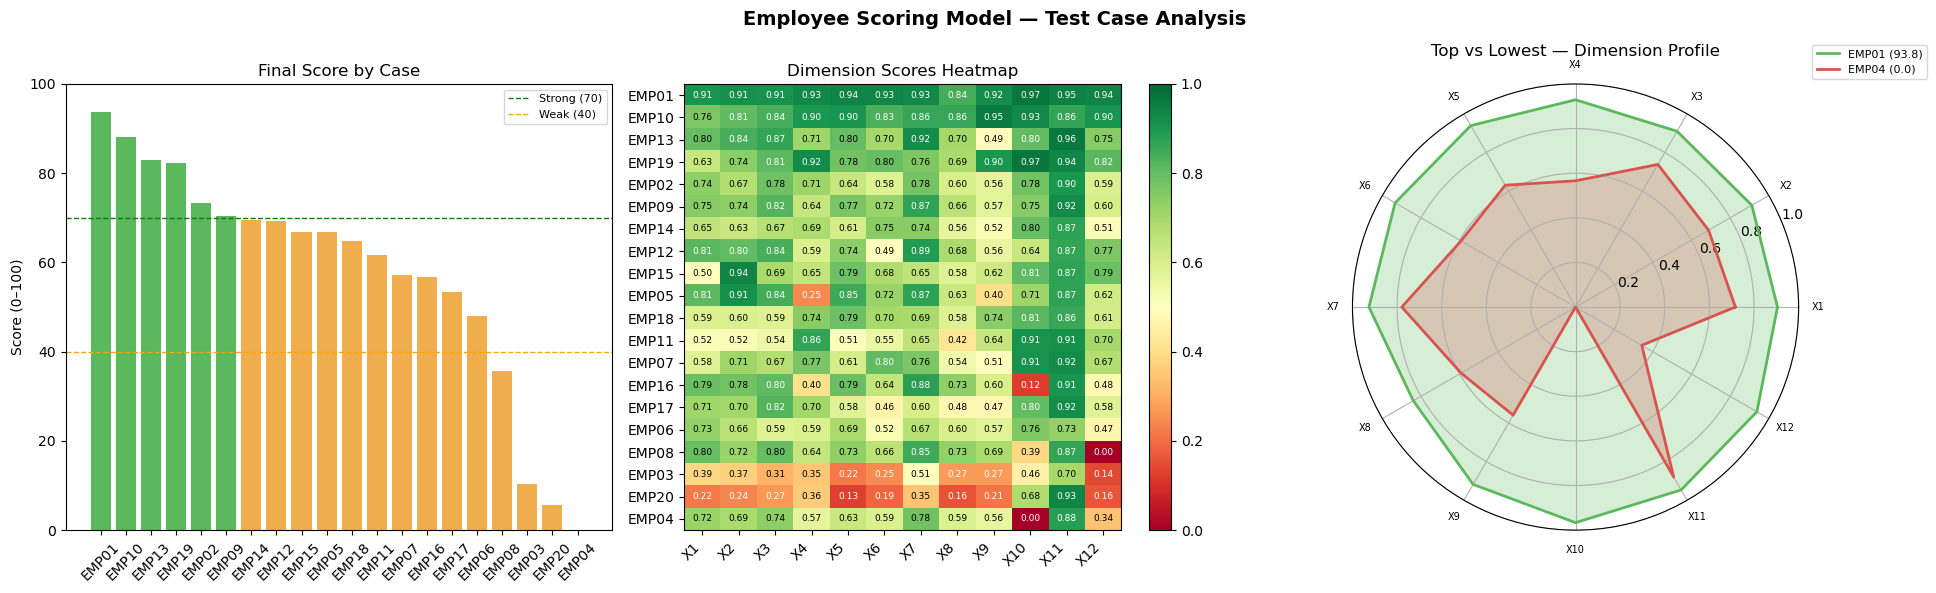

In [66]:
dim_cols = [f"X{i}" for i in range(1, 13)] 

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Employee Scoring Model — Test Case Analysis", fontsize=14, fontweight='bold')

colors = ["#d9534f" if s == 0 else "#5cb85c" if s >= 70 else "#f0ad4e"
          for s in df_sorted["Score"]]
axes[0].bar(df_sorted["Case ID"], df_sorted["Score"], color=colors)
axes[0].set_title("Final Score by Case")
axes[0].set_ylabel("Score (0–100)")
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(70, color="green", linestyle="--", linewidth=1, label="Strong (70)")
axes[0].axhline(40, color="orange", linestyle="--", linewidth=1, label="Weak (40)")
axes[0].legend(fontsize=8)

heat_data = df_sorted[dim_cols].values
im = axes[1].imshow(heat_data, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)
axes[1].set_xticks(range(len(dim_cols)))
axes[1].set_xticklabels([c.upper() for c in dim_cols], rotation=45, ha='right')
axes[1].set_yticks(range(len(df_sorted)))
axes[1].set_yticklabels(df_sorted["Case ID"])
axes[1].set_title("Dimension Scores Heatmap")
plt.colorbar(im, ax=axes[1])

for i in range(len(df_sorted)):
    for j in range(len(dim_cols)):
        axes[1].text(j, i, f"{heat_data[i, j]:.2f}",
                     ha="center", va="center", fontsize=6.5,
                     color="black" if 0.3 < heat_data[i, j] < 0.8 else "white")

top_vals = df_sorted.iloc[0][dim_cols].values.astype(float)
bot_vals = df_sorted.iloc[-1][dim_cols].values.astype(float)
labels   = [c.upper() for c in dim_cols]
N        = len(dim_cols)
angles   = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()

top_vals = np.append(top_vals, top_vals[0])
bot_vals = np.append(bot_vals, bot_vals[0])
angles  += angles[:1]

ax3 = axes[2]
ax3.remove()
ax3 = fig.add_subplot(1, 3, 3, polar=True)
ax3.plot(angles, top_vals, color="#5cb85c", linewidth=2,
         label=f"{df_sorted.iloc[0]['Case ID']} ({df_sorted.iloc[0]['Score']:.1f})")
ax3.fill(angles, top_vals, color="#5cb85c", alpha=0.25)
ax3.plot(angles, bot_vals, color="#d9534f", linewidth=2,
         label=f"{df_sorted.iloc[-1]['Case ID']} ({df_sorted.iloc[-1]['Score']:.1f})")
ax3.fill(angles, bot_vals, color="#d9534f", alpha=0.25)
ax3.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=7)
ax3.set_ylim(0, 1)
ax3.set_title("Top vs Lowest — Dimension Profile", pad=20)
ax3.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=8)

plt.tight_layout()
plt.show()


In [67]:
df_sorted.to_csv("employee_scores_results.csv", index=False)
print("Exported → employee_scores_results.csv")

Exported → employee_scores_results.csv
